In [1]:
# ---- Libraries ----
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (10, 5)

---
# Phase 1 — Dataset Collection

In [3]:
# NOTE: the file contains special characters (accented names such as cities/customers),
# so it is NOT plain UTF-8. Reading with encoding='latin-1' avoids a UnicodeDecodeError.
DATA_PATH = "sales_1.csv"      # change the path if your file is elsewhere
df = pd.read_csv(DATA_PATH, encoding="latin-1")

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [4]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [5]:
# Summary statistics of the numeric columns
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00,9994.00,51290.00,51290.00,51290.00,51290.00,51290.00
mean,25645.50,55190.38,246.49,3.48,0.14,28.61,26.38
std,14806.29,32063.69,487.57,2.28,0.21,174.34,57.30
min,1.00,1040.00,0.44,1.00,0.00,-6599.98,0.00
25%,12823.25,23223.00,30.76,2.00,0.00,0.00,2.61
50%,25645.50,56430.50,85.05,3.00,0.00,9.24,7.79
75%,38467.75,90008.00,251.05,5.00,0.20,36.81,24.45
max,51290.00,99301.00,22638.48,14.00,0.85,8399.98,933.57


---
# Phase 2 — Data Preprocessing

### 5.1 Missing values

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

Postal Code    41296
dtype: int64

In [9]:
df = df.drop(columns=["Postal Code"])
print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


### 5.2 Duplicate removal

In [11]:
print("Fully duplicated rows :", df.duplicated().sum())
print("Duplicated Row IDs    :", df["Row ID"].duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Fully duplicated rows : 0
Duplicated Row IDs    : 0
Shape after removing duplicates: (51290, 23)


### 5.3 Data type correction & date/time conversion

In [13]:
print(df[["Order Date", "Ship Date"]].head(3))

# The dates are written as day-month-year (e.g. 31-07-2012), so we tell pandas the format explicitly.
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%d-%m-%Y")

# Useful date parts for analysis
df["Year"]  = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()   # first day of the month

print("\nDate range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
df.dtypes

   Order Date   Ship Date
0  31-07-2012  31-07-2012
1  05-02-2013  07-02-2013
2  17-10-2013  18-10-2013

Date range: 2011-01-01 to 2014-12-31


Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
Year                       int32
Month                      int32
YearMonth         datetime64[ns]
dtype: object

### 5.4 Data consistency checks

In [15]:
checks = {
    "Ship Date earlier than Order Date": (df["Ship Date"] < df["Order Date"]).sum(),
    "Sales <= 0":                        (df["Sales"] <= 0).sum(),
    "Quantity <= 0":                     (df["Quantity"] <= 0).sum(),
    "Discount outside 0-1":              ((df["Discount"] < 0) | (df["Discount"] > 1)).sum(),
    "Sub-Categories mapped to >1 Category": (df.groupby("Sub-Category")["Category"].nunique() > 1).sum(),
}
pd.Series(checks, name="Number of problem rows")

Ship Date earlier than Order Date       0
Sales <= 0                              0
Quantity <= 0                           0
Discount outside 0-1                    0
Sub-Categories mapped to >1 Category    0
Name: Number of problem rows, dtype: int64

**Result:** all checks return 0, so the data is logically consistent (no negative sales/quantity, valid discounts, valid shipping dates, clean product hierarchy).

### 5.5 Outlier identification

Upper outlier limit for Sales: 581.50
Outlier rows: 5655 (11.0% of data)


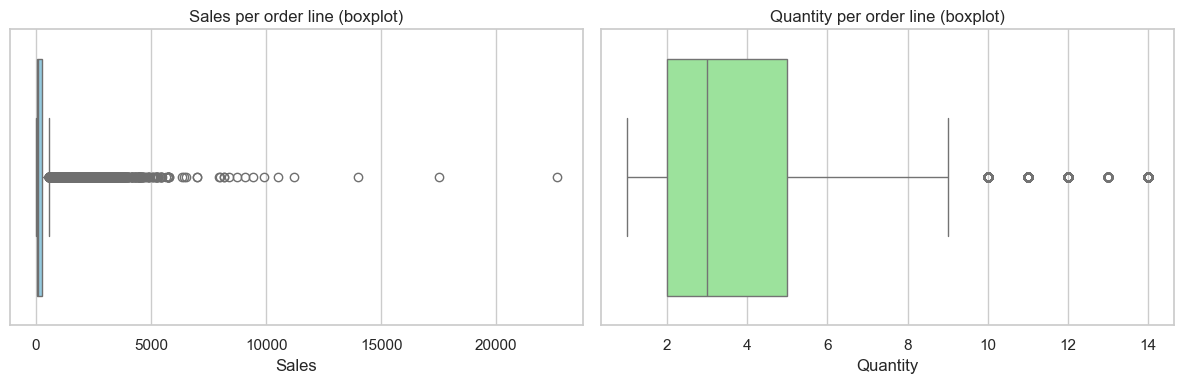

In [18]:
# IQR rule: a value is an outlier if it lies beyond 1.5 x IQR from the quartiles
Q1, Q3 = df["Sales"].quantile(0.25), df["Sales"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
n_out = (df["Sales"] > upper).sum()
print(f"Upper outlier limit for Sales: {upper:.2f}")
print(f"Outlier rows: {n_out} ({n_out / len(df) * 100:.1f}% of data)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Sales"], ax=ax[0], color="skyblue")
ax[0].set_title("Sales per order line (boxplot)")
sns.boxplot(x=df["Quantity"], ax=ax[1], color="lightgreen")
ax[1].set_title("Quantity per order line (boxplot)")
plt.tight_layout()
plt.show()

### 5.6 Dropping columns that do not help prediction

In [20]:
# IDs and personal names are identifiers, not business drivers. City/State/Country are too detailed
# (147 countries) - we use the broader Market and Region columns for location instead.
drop_cols = ["Row ID", "Order ID", "Customer ID", "Customer Name", "Product ID",
             "City", "State", "Ship Mode", "Order Priority", "Shipping Cost"]
df_clean = df.drop(columns=drop_cols)
print("Columns kept:", list(df_clean.columns))
print("Clean shape:", df_clean.shape)

Columns kept: ['Order Date', 'Ship Date', 'Segment', 'Country', 'Market', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'YearMonth']
Clean shape: (51290, 16)



# Phase 3 — Exploratory Data Analysis (EDA)

## 6. Exploratory Data Analysis

### 6.1 Monthly sales trend

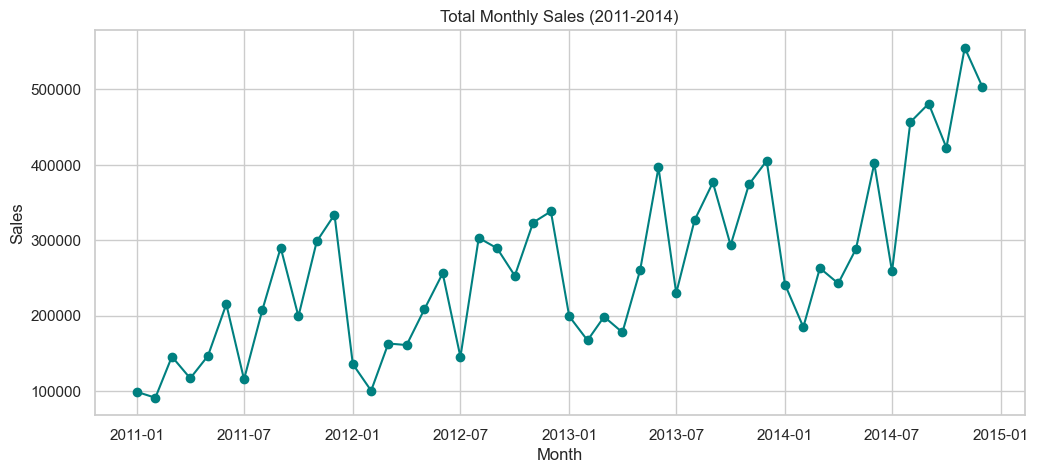

Year
2011    2.26
2012    2.68
2013    3.41
2014    4.30
Name: Total sales (millions), dtype: float64

Year-on-year growth (%):
Year
2012    18.5
2013    27.2
2014    26.3
Name: Sales, dtype: float64


In [24]:
monthly_total = df_clean.groupby("YearMonth")["Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_total.index, monthly_total.values, marker="o", color="teal")
plt.title("Total Monthly Sales (2011-2014)")
plt.xlabel("Month"); plt.ylabel("Sales")
plt.show()

yearly = df_clean.groupby("Year")["Sales"].sum()
print((yearly / 1e6).round(2).rename("Total sales (millions)"))
print("\nYear-on-year growth (%):")
print((yearly.pct_change() * 100).round(1).dropna())

**Observation:** sales show a clear **upward trend** year after year, with repeating peaks toward the end of each year (see seasonality below).

### 6.2 Product-wise sales (high & low performers)

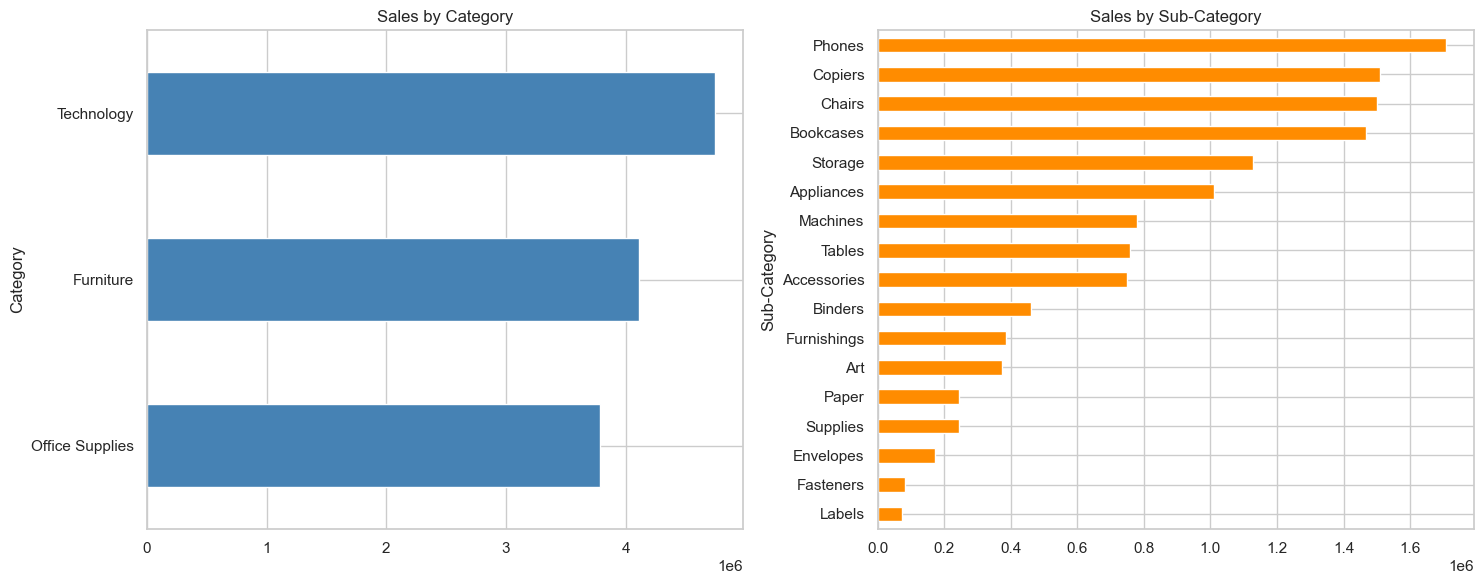

Top 3 sub-categories   : ['Phones', 'Copiers', 'Chairs']
Bottom 3 sub-categories: ['Labels', 'Fasteners', 'Envelopes']


In [27]:
cat_sales = df_clean.groupby("Category")["Sales"].sum().sort_values()
sub_sales = df_clean.groupby("Sub-Category")["Sales"].sum().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
cat_sales.plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Sales by Category")
sub_sales.plot(kind="barh", ax=ax[1], color="darkorange")
ax[1].set_title("Sales by Sub-Category")
plt.tight_layout()
plt.show()

print("Top 3 sub-categories   :", list(sub_sales.tail(3).index[::-1]))
print("Bottom 3 sub-categories:", list(sub_sales.head(3).index))

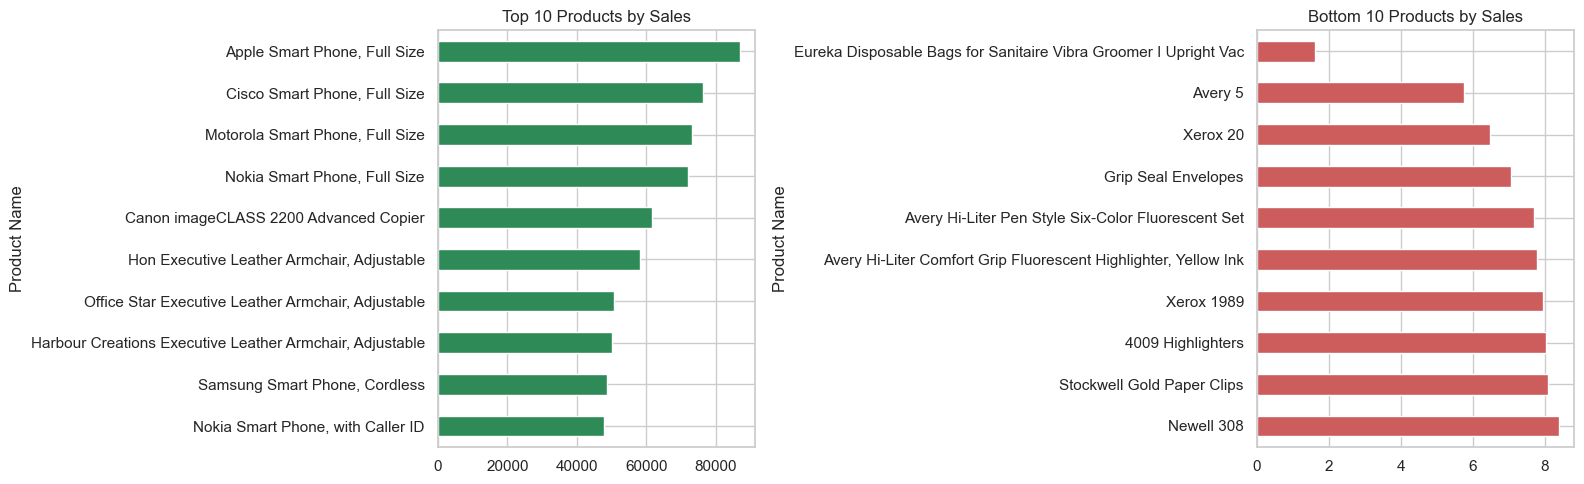

In [28]:
# Individual products: top 10 and bottom 10 by total sales
prod_sales = df_clean.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
prod_sales.head(10).sort_values().plot(kind="barh", ax=ax[0], color="seagreen")
ax[0].set_title("Top 10 Products by Sales")
prod_sales.tail(10).sort_values(ascending=False).plot(kind="barh", ax=ax[1], color="indianred")
ax[1].set_title("Bottom 10 Products by Sales")
plt.tight_layout()
plt.show()

### 6.3 Region-wise sales

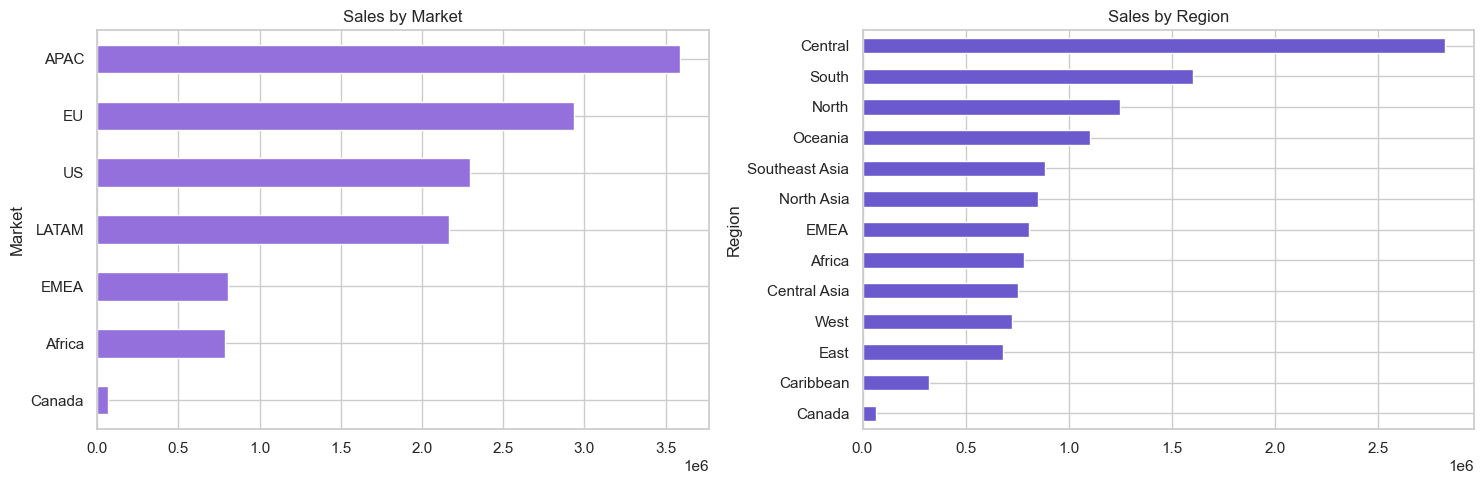

In [30]:
market_sales = df_clean.groupby("Market")["Sales"].sum().sort_values()
region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
market_sales.plot(kind="barh", ax=ax[0], color="mediumpurple")
ax[0].set_title("Sales by Market")
region_sales.plot(kind="barh", ax=ax[1], color="slateblue")
ax[1].set_title("Sales by Region")
plt.tight_layout()
plt.show()

### 6.4 Quantity trend

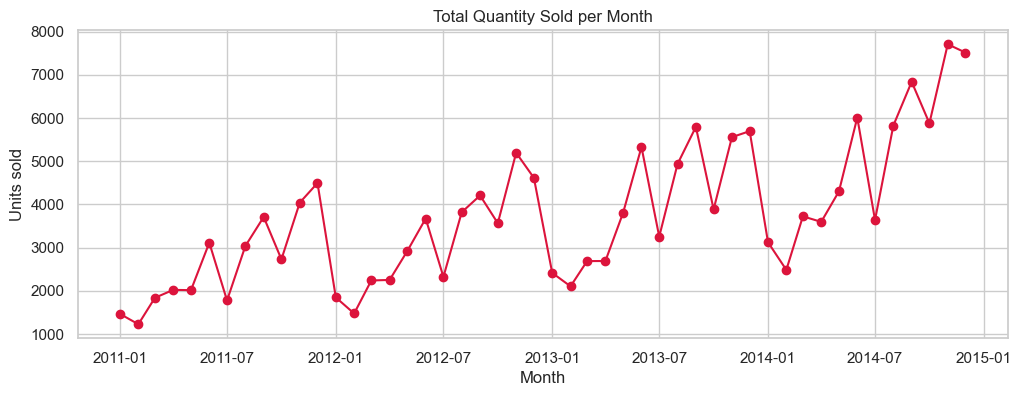

In [32]:
monthly_qty = df_clean.groupby("YearMonth")["Quantity"].sum()

plt.figure(figsize=(12, 4))
plt.plot(monthly_qty.index, monthly_qty.values, marker="o", color="crimson")
plt.title("Total Quantity Sold per Month")
plt.xlabel("Month"); plt.ylabel("Units sold")
plt.show()

### 6.5 Price vs. sales relationship

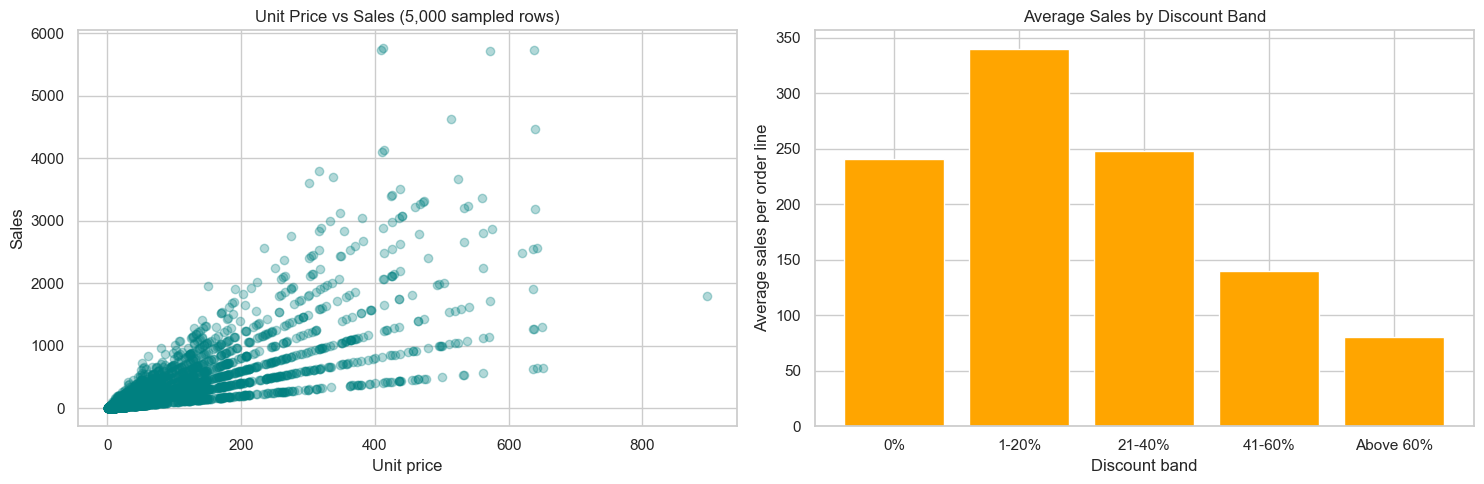

Correlation between Unit Price and Sales: 0.81

Average sales per order line by discount band:
Discount
0%           241.0
1-20%        339.6
21-40%       248.2
41-60%       139.9
Above 60%     80.5
Name: Sales, dtype: float64


In [34]:
# Selling price per unit = Sales / Quantity (this is the price AFTER discount)
df_clean["Unit_Price"] = df_clean["Sales"] / df_clean["Quantity"]

sample = df_clean.sample(5000, random_state=42)        # sample so the plot is readable

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(sample["Unit_Price"], sample["Sales"], alpha=0.3, color="teal")
ax[0].set_xlabel("Unit price"); ax[0].set_ylabel("Sales")
ax[0].set_title("Unit Price vs Sales (5,000 sampled rows)")

# Group the many discount values into simple bands so the chart is readable
bands = pd.cut(df_clean["Discount"], bins=[-0.01, 0, 0.2, 0.4, 0.6, 1.0],
               labels=["0%", "1-20%", "21-40%", "41-60%", "Above 60%"])
disc_sales = df_clean.groupby(bands, observed=True)["Sales"].mean()
ax[1].bar(disc_sales.index.astype(str), disc_sales.values, color="orange")
ax[1].set_xlabel("Discount band"); ax[1].set_ylabel("Average sales per order line")
ax[1].set_title("Average Sales by Discount Band")
plt.tight_layout()
plt.show()

print("Correlation between Unit Price and Sales:", round(df_clean["Unit_Price"].corr(df_clean["Sales"]), 2))
print("\nAverage sales per order line by discount band:")
print(disc_sales.round(1))

### 6.6 Seasonal patterns

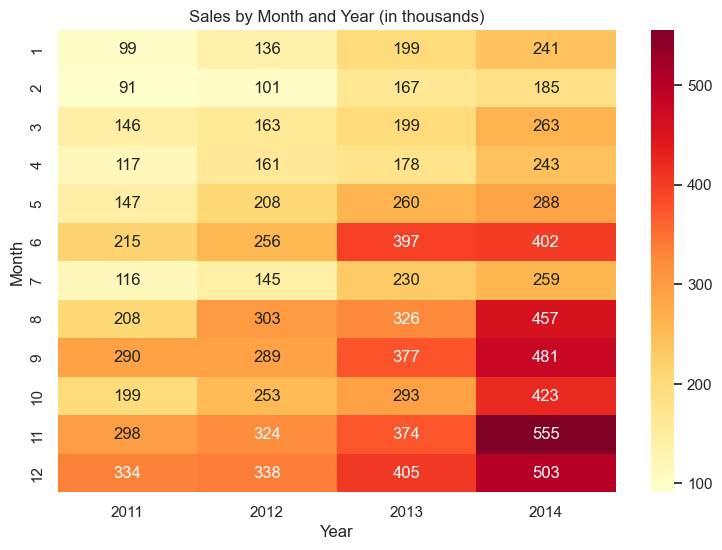

Strongest months: [12, 11, 9]
Weakest months  : [2, 1, 4]


In [36]:
season = df_clean.pivot_table(index="Month", columns="Year", values="Sales", aggfunc="sum")

plt.figure(figsize=(9, 6))
sns.heatmap(season / 1000, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Sales by Month and Year (in thousands)")
plt.show()

avg_month = df_clean.groupby("Month")["Sales"].sum()
print("Strongest months:", list(avg_month.sort_values(ascending=False).head(3).index))
print("Weakest months  :", list(avg_month.sort_values().head(3).index))

### 6.7 Correlation between numeric columns

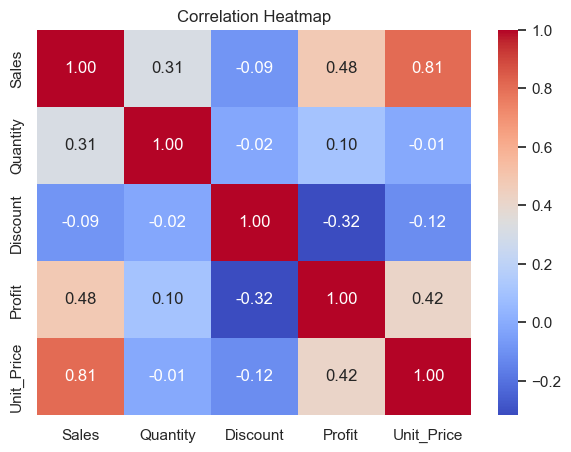

In [38]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[["Sales", "Quantity", "Discount", "Profit", "Unit_Price"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Phase 4 — Feature Engineering
## 7. Feature Engineering

In [40]:
monthly = (df_clean
           .groupby(["Sub-Category", "Market", "YearMonth"])
           .agg(Sales=("Sales", "sum"),
                Total_Quantity=("Quantity", "sum"),
                Avg_Discount=("Discount", "mean"))
           .reset_index())

# Average selling price per unit in that month (after discount)
monthly["Avg_Price"] = monthly["Sales"] / monthly["Total_Quantity"]
print(monthly.shape)
monthly.head()

(5008, 7)


,Sub-Category,Market,YearMonth,Sales,Total_Quantity,Avg_Discount,Avg_Price
0,Accessories,APAC,2011-01-01,630.4908,13,0.355000,48.499292
1,Accessories,APAC,2011-02-01,1199.5125,14,0.241667,85.679464
2,Accessories,APAC,2011-03-01,1194.4770,29,0.040000,41.188862
3,Accessories,APAC,2011-04-01,1186.0431,28,0.283750,42.358682
4,Accessories,APAC,2011-05-01,5295.9600,52,0.072727,101.845385


In [41]:
all_months = pd.date_range("2011-01-01", "2014-12-01", freq="MS")
full_index = pd.MultiIndex.from_product(
    [monthly["Sub-Category"].unique(), monthly["Market"].unique(), all_months],
    names=["Sub-Category", "Market", "YearMonth"])

full = (monthly.set_index(["Sub-Category", "Market", "YearMonth"])
               .reindex(full_index)
               .reset_index()
               .sort_values(["Sub-Category", "Market", "YearMonth"]))

full["Sales"] = full["Sales"].fillna(0)
print("Rows in complete calendar:", len(full))
print("Months with zero sales   :", (full["Sales"] == 0).sum())

Rows in complete calendar: 5712
Months with zero sales   : 704


In [42]:
group = full.groupby(["Sub-Category", "Market"])["Sales"]

full["Prev_Sales"]  = group.shift(1)                                                              # last month
full["Avg_Prev_3"]  = group.transform(lambda s: s.shift(1).rolling(3,  min_periods=1).mean())     # last 3 months
full["Avg_Prev_6"]  = group.transform(lambda s: s.shift(1).rolling(6,  min_periods=1).mean())     # last 6 months
full["Avg_Prev_12"] = group.transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())     # last 12 months

# NEW: same calendar month one year ago. Rolling averages smooth seasonality away, so on their own
# they can't tell the model "December is naturally huge" - this feature gives that signal directly.
full["Sales_LastYear_SameMonth"] = group.shift(12)
full["Sales_LastYear_SameMonth"] = full["Sales_LastYear_SameMonth"].fillna(full["Prev_Sales"])   # fallback for a series' first year

full["Year"]     = full["YearMonth"].dt.year
full["Month"]    = full["YearMonth"].dt.month
full["Quarter"]  = full["YearMonth"].dt.quarter

# NEW: a product/market pairing with zero sales in a given month still "exists" - carry forward the
# last known price/discount instead of leaving them blank, so those months can stay in the model.
price_group = full.groupby(["Sub-Category", "Market"])
full["Avg_Price"]    = price_group["Avg_Price"].ffill()
full["Avg_Discount"] = price_group["Avg_Discount"].ffill()
full["Discount_Pct"] = full["Avg_Discount"] * 100

# CHANGED: we used to drop every month with zero sales. That hid roughly 700 real "no demand" months
# from the model, so it never learned what low/zero demand looks like and consistently mispriced
# quiet months (see the bias check in Phase 6). We now keep them, and only drop rows that truly have
# no history yet (the first month of a product/market pairing, before there is a Prev_Sales or
# Avg_Price to work with).
model_df = full.dropna(subset=["Prev_Sales", "Avg_Price", "Sales_LastYear_SameMonth"]).copy()

print("Final modelling table:", model_df.shape)
print("Zero-sales months included in training data:", (model_df["Sales"] == 0).sum())
model_df[["YearMonth", "Sub-Category", "Market", "Sales", "Prev_Sales", "Avg_Prev_3",
          "Avg_Prev_6", "Avg_Prev_12", "Sales_LastYear_SameMonth", "Discount_Pct", "Avg_Price",
          "Month", "Quarter"]].head()

Final modelling table: (5514, 16)
Zero-sales months included in training data: 604


,YearMonth,Sub-Category,Market,Sales,Prev_Sales,Avg_Prev_3,Avg_Prev_6,Avg_Prev_12,Sales_LastYear_SameMonth,Discount_Pct,Avg_Price,Month,Quarter
1,2011-02-01,Accessories,APAC,1199.5125,630.4908,630.49080,630.49080,630.49080,630.4908,24.166667,85.679464,2,1
2,2011-03-01,Accessories,APAC,1194.4770,1199.5125,915.00165,915.00165,915.00165,1199.5125,4.000000,41.188862,3,1
3,2011-04-01,Accessories,APAC,1186.0431,1194.4770,1008.16010,1008.16010,1008.16010,1194.4770,28.375000,42.358682,4,2
4,2011-05-01,Accessories,APAC,5295.9600,1186.0431,1193.34420,1052.63085,1052.63085,1186.0431,7.272727,101.845385,5,2
5,2011-06-01,Accessories,APAC,4533.8532,5295.9600,2558.82670,1901.29668,1901.29668,5295.9600,16.133333,90.677064,6,2


In [43]:
num_features = ["Month", "Quarter", "Prev_Sales", "Avg_Prev_3", "Avg_Prev_6", "Avg_Prev_12",
                "Sales_LastYear_SameMonth", "Discount_Pct", "Avg_Price"]
cat_features = ["Sub-Category", "Market"]

X = pd.get_dummies(model_df[num_features + cat_features], columns=cat_features)
y = model_df["Sales"]

train_mask = model_df["Year"] < 2014
test_mask  = model_df["Year"] == 2014

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Training rows (2011-2013):", X_train.shape[0])
print("Testing rows  (2014)     :", X_test.shape[0])
print("Number of input features :", X_train.shape[1])

Training rows (2011-2013): 4086
Testing rows  (2014)     : 1428
Number of input features : 33


In [44]:
REF_FLOOR = 200      # minimum reference level (avoids dividing by tiny numbers)
RATIO_CAP = 8        # maximum allowed ratio (limits extreme values)

ref   = np.maximum(model_df["Avg_Prev_12"], REF_FLOOR)          # reference level for every row
ratio = (model_df["Sales"] / ref).clip(upper=RATIO_CAP)          # the new target

ref_train, ref_test = ref[train_mask].values, ref[test_mask].values
ratio_train = ratio[train_mask]

print("Rows where the cap was applied:", int((model_df["Sales"] / ref > RATIO_CAP).sum()), "of", len(model_df))
print("\nRatio summary (1.0 = same as recent normal level):")
print(ratio.describe().round(2))

Rows where the cap was applied: 22 of 5514

Ratio summary (1.0 = same as recent normal level):
count    5514.00
mean        1.10
std         1.07
min         0.00
25%         0.37
50%         0.89
75%         1.53
max         8.00
dtype: float64


In [45]:
# name -> (model, does it predict the ratio?)
experiments = {
    "Linear Regression (raw sales)": (LinearRegression(), False),
    "Decision Tree (raw sales)":     (DecisionTreeRegressor(max_depth=6, random_state=42), False),
    "Random Forest (raw sales)":     (RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
    "Decision Tree (ratio)":         (DecisionTreeRegressor(max_depth=6, random_state=42), True),
    "Random Forest (ratio)":         (RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), True),
    "Gradient Boosting (ratio)":     (GradientBoostingRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                                                                subsample=0.8, random_state=42), True),
}

models, uses_ratio = {}, {}
predictions, train_predictions = {}, {}

for name, (model, ratio_flag) in experiments.items():
    if ratio_flag:
        model.fit(X_train, ratio_train)                                       # learn the ratio from 2011-2013
        predictions[name]       = np.maximum(model.predict(X_test)  * ref_test,  0)   # ratio x reference = sales (2014)
        train_predictions[name] = np.maximum(model.predict(X_train) * ref_train, 0)
    else:
        model.fit(X_train, y_train)                                           # learn sales directly
        predictions[name]       = np.maximum(model.predict(X_test),  0)
        train_predictions[name] = np.maximum(model.predict(X_train), 0)
    models[name], uses_ratio[name] = model, ratio_flag
    print("Trained:", name)

# Naive baseline for comparison
naive_pred = X_test["Prev_Sales"].values

Trained: Linear Regression (raw sales)
Trained: Decision Tree (raw sales)
Trained: Random Forest (raw sales)
Trained: Decision Tree (ratio)
Trained: Random Forest (ratio)
Trained: Gradient Boosting (ratio)


---
# Phase 6 — Model Evaluation


In [47]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

rows = [["Naive baseline (last month)", *evaluate(y_test, naive_pred), np.nan]]
for name in models:
    rows.append([name, *evaluate(y_test, predictions[name]), r2_score(y_train, train_predictions[name])])

results = pd.DataFrame(rows, columns=["Model", "MAE", "MSE", "RMSE", "R2 (test)", "R2 (train)"]).set_index("Model")
results.round(3)

,MAE,MSE,RMSE,R2 (test),R2 (train)
Model,,,,,
Naive baseline (last month),1739.657,1.011385e+07,3180.229,0.455,NaN
Linear Regression (raw sales),1308.307,5.713927e+06,2390.382,0.692,0.655
Decision Tree (raw sales),1390.432,6.579706e+06,2565.094,0.645,0.744
Random Forest (raw sales),1221.682,4.978795e+06,2231.321,0.732,0.933
Decision Tree (ratio),1319.064,6.172735e+06,2484.499,0.667,0.608
Random Forest (ratio),1155.269,4.523083e+06,2126.754,0.756,0.828
Gradient Boosting (ratio),1079.649,3.949136e+06,1987.243,0.787,0.814


### 6b. Robustness check: rolling-origin cross-validation

A single 2014 hold-out is only one test. To check the Random Forest and Gradient Boosting results above aren't a fluke of that particular year, we re-validate them with `TimeSeriesSplit`: each fold trains on an earlier chunk of the 2011-2013 data and validates on the period right after it, sliding forward in time so no future data ever leaks into training.

In [97]:
train_sorted        = model_df[train_mask].sort_values("YearMonth")
X_train_sorted      = X.loc[train_sorted.index].reset_index(drop=True)
y_train_sorted      = y.loc[train_sorted.index].reset_index(drop=True)
ratio_train_sorted  = ratio.loc[train_sorted.index].reset_index(drop=True)
ref_train_sorted    = ref.loc[train_sorted.index].reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

cv_model_specs = {
    "Random Forest (ratio)":     RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting (ratio)": GradientBoostingRegressor(n_estimators=400, learning_rate=0.03, max_depth=4,
                                                            subsample=0.8, random_state=42),
}

cv_scores = {name: [] for name in cv_model_specs}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sorted), start=1):
    for name, base_model in cv_model_specs.items():
        model = clone(base_model)
        model.fit(X_train_sorted.iloc[tr_idx], ratio_train_sorted.iloc[tr_idx])
        val_pred = np.maximum(model.predict(X_train_sorted.iloc[val_idx]) * ref_train_sorted.iloc[val_idx].values, 0)
        rmse = np.sqrt(mean_squared_error(y_train_sorted.iloc[val_idx], val_pred))
        cv_scores[name].append(rmse)
        print(f"Fold {fold} | {name:<28} RMSE: {rmse:,.0f}")

cv_summary = pd.DataFrame({name: {"Mean RMSE": np.mean(scores), "Std RMSE": np.std(scores)}
                            for name, scores in cv_scores.items()}).T
print("\n5-fold rolling-origin cross-validation summary (2011-2013 training data):")
cv_summary.round(1)

Fold 1 | Random Forest (ratio)        RMSE: 2,473
Fold 1 | Gradient Boosting (ratio)    RMSE: 2,397
Fold 2 | Random Forest (ratio)        RMSE: 1,836
Fold 2 | Gradient Boosting (ratio)    RMSE: 1,708
Fold 3 | Random Forest (ratio)        RMSE: 2,028
Fold 3 | Gradient Boosting (ratio)    RMSE: 1,855
Fold 4 | Random Forest (ratio)        RMSE: 1,781
Fold 4 | Gradient Boosting (ratio)    RMSE: 1,745
Fold 5 | Random Forest (ratio)        RMSE: 2,157
Fold 5 | Gradient Boosting (ratio)    RMSE: 2,022

5-fold rolling-origin cross-validation summary (2011-2013 training data):


,Mean RMSE,Std RMSE
Random Forest (ratio),2055.0,248.4
Gradient Boosting (ratio),1945.3,250.8


Best model: Gradient Boosting (ratio)


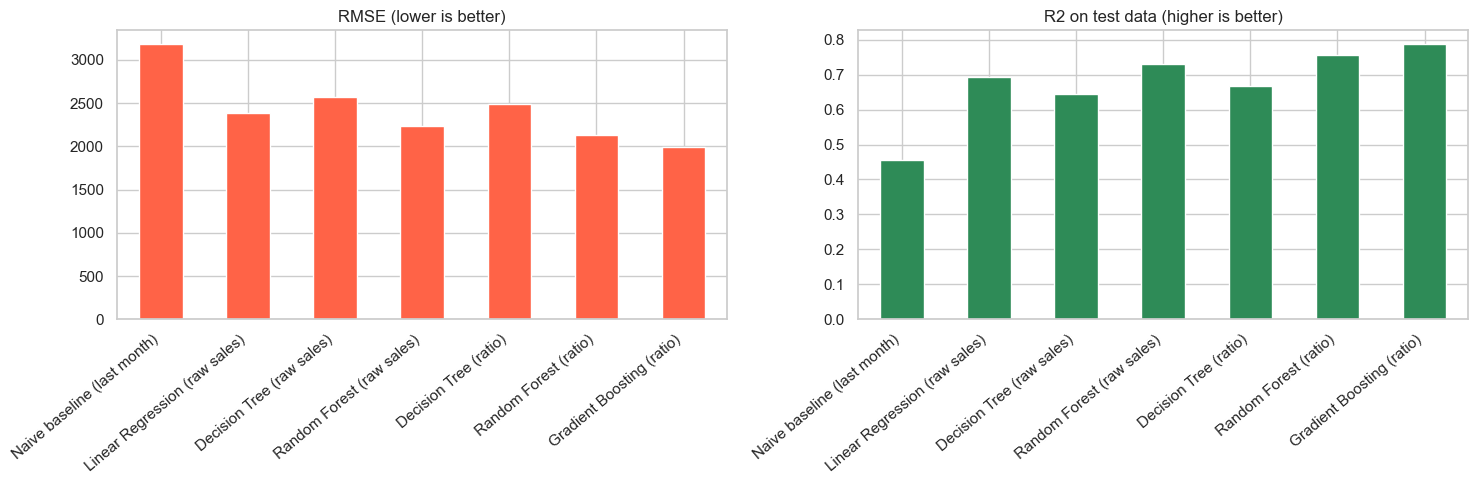

In [99]:
# Pick the best ML model automatically: lowest RMSE on the test set
best_name  = results.drop("Naive baseline (last month)")["RMSE"].idxmin()
best_model = models[best_name]
best_pred  = predictions[best_name]
print("Best model:", best_name)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
results["RMSE"].plot(kind="bar", ax=ax[0], color="tomato")
ax[0].set_title("RMSE (lower is better)")
results["R2 (test)"].plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("R2 on test data (higher is better)")
for a in ax:
    a.set_xlabel("")
    a.tick_params(axis="x", rotation=40)
    for label in a.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

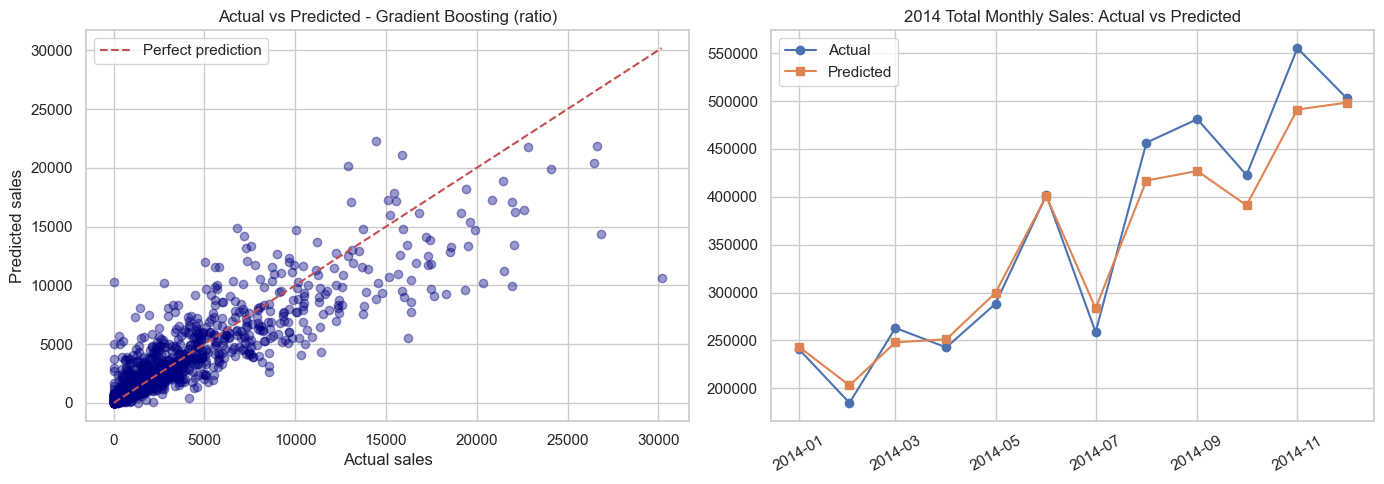

In [100]:
# Actual vs Predicted for the best model
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, best_pred, alpha=0.4, color="navy")
lim = max(y_test.max(), best_pred.max())
ax[0].plot([0, lim], [0, lim], "r--", label="Perfect prediction")
ax[0].set_xlabel("Actual sales"); ax[0].set_ylabel("Predicted sales")
ax[0].set_title(f"Actual vs Predicted - {best_name}")
ax[0].legend()

# Total sales per month: actual vs predicted (all products & markets added together)
cmp = pd.DataFrame({"YearMonth": model_df.loc[test_mask, "YearMonth"].values,
                    "Actual": y_test.values, "Predicted": best_pred}).groupby("YearMonth").sum()
ax[1].plot(cmp.index, cmp["Actual"], marker="o", label="Actual")
ax[1].plot(cmp.index, cmp["Predicted"], marker="s", label="Predicted")
ax[1].set_title("2014 Total Monthly Sales: Actual vs Predicted")
ax[1].tick_params(axis="x", rotation=30)
ax[1].legend()
plt.tight_layout()
plt.show()

In [103]:
# Is the model biased? Compare the TOTAL predicted sales with the TOTAL actual sales in 2014
bias = pd.DataFrame({name: [p.sum()] for name, p in predictions.items()}, index=["Predicted total"]).T
bias["Actual total"] = y_test.sum()
bias["Predicted as % of actual"] = (bias["Predicted total"] / bias["Actual total"] * 100).round(1)
bias.round(0)

,Predicted total,Actual total,Predicted as % of actual
Linear Regression (raw sales),4116826.0,4299866.0,96.0
Decision Tree (raw sales),4007340.0,4299866.0,93.0
Random Forest (raw sales),4063210.0,4299866.0,94.0
Decision Tree (ratio),4641580.0,4299866.0,108.0
Random Forest (ratio),4324601.0,4299866.0,101.0
Gradient Boosting (ratio),4154885.0,4299866.0,97.0


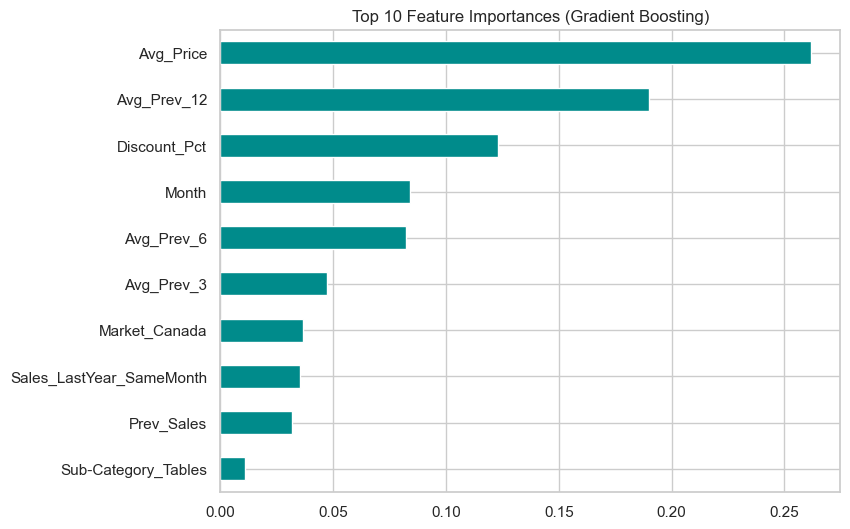

Avg_Price       0.262
Avg_Prev_12     0.190
Discount_Pct    0.123
Month           0.084
Avg_Prev_6      0.082
Avg_Prev_3      0.047
dtype: float64

In [105]:
# Which features matter most? (Gradient Boosting)
importances = pd.Series(models["Gradient Boosting (ratio)"].feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 6))
importances.tail(10).plot(kind="barh", color="darkcyan")
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.show()

importances.sort_values(ascending=False).head(6).round(3)

---
# Phase 7 — Sales Prediction

In [108]:
joblib.dump({"model": best_model,
             "columns": list(X_train.columns),
             "name": best_name,
             "uses_ratio": uses_ratio[best_name],
             "ref_floor": REF_FLOOR},
            "sales_prediction_model.joblib")
print("Model saved as sales_prediction_model.joblib  (", best_name, ")")

Model saved as sales_prediction_model.joblib  ( Gradient Boosting (ratio) )


In [110]:
saved = joblib.load("sales_prediction_model.joblib")

def predict_sales(sub_category, market, month, prev_sales, avg_price, discount_pct,
                  avg_prev_3=None, avg_prev_6=None, avg_prev_12=None, sales_last_year=None):
    '''Predict the total monthly sales for one product sub-category in one market.'''
    if avg_prev_3  is None: avg_prev_3  = prev_sales
    if avg_prev_6  is None: avg_prev_6  = avg_prev_3
    if avg_prev_12 is None: avg_prev_12 = avg_prev_6
    if sales_last_year is None: sales_last_year = prev_sales     # fallback when no year-ago figure is known

    row = pd.DataFrame([{
        "Month": month, "Quarter": (month - 1) // 3 + 1,
        "Prev_Sales": prev_sales, "Avg_Prev_3": avg_prev_3,
        "Avg_Prev_6": avg_prev_6, "Avg_Prev_12": avg_prev_12,
        "Sales_LastYear_SameMonth": sales_last_year,
        "Discount_Pct": discount_pct, "Avg_Price": avg_price,
        "Sub-Category": sub_category, "Market": market}])

    row = pd.get_dummies(row, columns=["Sub-Category", "Market"])
    row = row.reindex(columns=saved["columns"], fill_value=0)      # match the training columns
    pred = saved["model"].predict(row)[0]

    if saved["uses_ratio"]:                                        # convert ratio back to sales
        pred = pred * max(avg_prev_12, saved["ref_floor"])
    return max(pred, 0)

# ----- Example (same style as the assignment) -----
example = dict(sub_category="Phones", market="APAC", month=9,
               prev_sales=9000, avg_price=180, discount_pct=5)
pred = predict_sales(**example)

print("Product        :", example["sub_category"])
print("Market         :", example["market"])
print("Month          : September")
print("Previous Sales :", example["prev_sales"])
print("Average Price  :", example["avg_price"])
print("Discount       :", example["discount_pct"], "%")
print(f"\nPredicted Sales for the month: {pred:,.0f}")

Product        : Phones
Market         : APAC
Month          : September
Previous Sales : 9000
Average Price  : 180
Discount       : 5 %

Predicted Sales for the month: 10,647


## Product-wise forecast for the next month (January 2015)
Optional enhancement: we use the latest known data (end of 2014) to predict January 2015 sales for every
Sub-Category in one market.

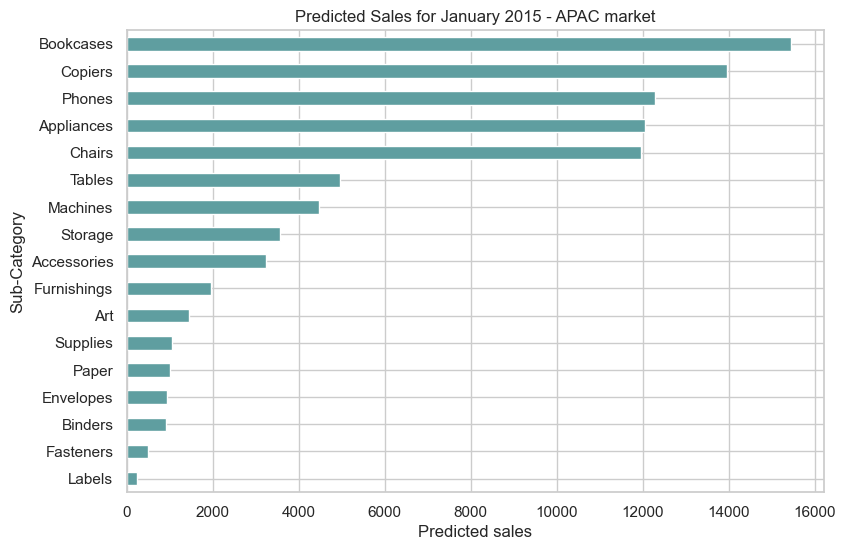

Predicted total for Jan 2015 (APAC): 90,019   |   Actual Jan 2014: 79,182


,Sub-Category,Predicted_Sales
0,Bookcases,15439.0
1,Copiers,13948.0
2,Phones,12283.0
3,Appliances,12054.0
4,Chairs,11954.0


In [113]:
market_choice = "APAC"
next_month = 1
rows = []

for sub in sorted(full["Sub-Category"].unique()):
    s = full[(full["Sub-Category"] == sub) & (full["Market"] == market_choice)].sort_values("YearMonth")
    rows.append({
        "Sub-Category": sub,
        "Predicted_Sales": predict_sales(
            sub, market_choice, next_month,
            prev_sales=s["Sales"].iloc[-1],
            avg_prev_3=s["Sales"].iloc[-3:].mean(),
            avg_prev_6=s["Sales"].iloc[-6:].mean(),
            avg_prev_12=s["Sales"].iloc[-12:].mean(),
            sales_last_year=(s["Sales"].iloc[-12] if len(s) >= 12 else None),  # NEW: same month last year
            avg_price=s["Avg_Price"].dropna().tail(3).mean(),        # recent average price
            discount_pct=s["Discount_Pct"].dropna().tail(3).mean())  # recent average discount
    })

forecast = pd.DataFrame(rows).sort_values("Predicted_Sales")
forecast.set_index("Sub-Category")["Predicted_Sales"].plot(kind="barh", figsize=(9, 6), color="cadetblue")
plt.title(f"Predicted Sales for January 2015 - {market_choice} market")
plt.xlabel("Predicted sales")
plt.show()

# Sanity check: is the predicted total reasonable compared with the same month last year?
jan_2014 = full[(full["Market"] == market_choice) & (full["YearMonth"] == "2014-01-01")]["Sales"].sum()
print(f"Predicted total for Jan 2015 ({market_choice}): {forecast['Predicted_Sales'].sum():,.0f}   |   Actual Jan 2014: {jan_2014:,.0f}")

forecast.sort_values("Predicted_Sales", ascending=False).round(0).reset_index(drop=True).head(5)

## Final prediction results (saved to CSV)

In [116]:
final_results = model_df.loc[test_mask, ["YearMonth", "Sub-Category", "Market"]].copy()
final_results["Actual_Sales"]    = y_test.values.round(2)
final_results["Predicted_Sales"] = best_pred.round(2)
final_results["Error"]           = (final_results["Predicted_Sales"] - final_results["Actual_Sales"]).round(2)

final_results.to_csv("final_prediction_results.csv", index=False)
print("Saved final_prediction_results.csv with", len(final_results), "rows")
final_results.head(10)

Saved final_prediction_results.csv with 1428 rows


,YearMonth,Sub-Category,Market,Actual_Sales,Predicted_Sales,Error
36,2014-01-01,Accessories,APAC,3575.80,2208.77,-1367.03
37,2014-02-01,Accessories,APAC,5507.23,2406.09,-3101.14
38,2014-03-01,Accessories,APAC,1435.08,2207.04,771.96
39,2014-04-01,Accessories,APAC,4822.41,3129.75,-1692.66
40,2014-05-01,Accessories,APAC,8147.13,3511.17,-4635.96
41,2014-06-01,Accessories,APAC,5567.72,5148.57,-419.15
42,2014-07-01,Accessories,APAC,2977.43,3289.89,312.46
43,2014-08-01,Accessories,APAC,4154.33,5877.08,1722.75
44,2014-09-01,Accessories,APAC,3955.06,6043.95,2088.89
45,2014-10-01,Accessories,APAC,4943.75,5976.93,1033.18
